# Phase 3 -- Visualization of Latent Structure

## Objective

Visualize tumor samples in the reduced SVD space to assess whether cancer types form distinguishable clusters. We project the 801 samples onto the first few SVD components and color them by cancer type.

If the SVD decomposition captures biologically meaningful variation, samples of the same cancer type should group together in the projected space. We also compare SVD projections with PCA projections for validation.

In [24]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
import os
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.linear_algebra.svd_core import compute_truncated_svd
from src.visualization.svd_projection_plots import (
    plot_svd_2d,
    plot_svd_3d
)
from src.visualization.pca_projection_plots import plot_pca_2d


In [25]:
X = pd.read_csv(r"../Data/processed/X_processed.csv").values
y = pd.read_csv(r"../Data/processed/labels.csv").iloc[:, 0].values


In [26]:
U_reduced, singular_values, svd_model = compute_truncated_svd(
    X,
    n_components=10
)


## 3.1 SVD Dimensionality Reduction

We compute Truncated SVD with 10 components and encode the cancer type labels as integers for color mapping in the plots below.

In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


## 3.2 2D SVD Projection

Scatter plot of all samples using SVD Component 1 (x-axis) and SVD Component 2 (y-axis), colored by cancer type. Distinct spatial groupings indicate that the first two singular vectors already capture meaningful inter-class variation.

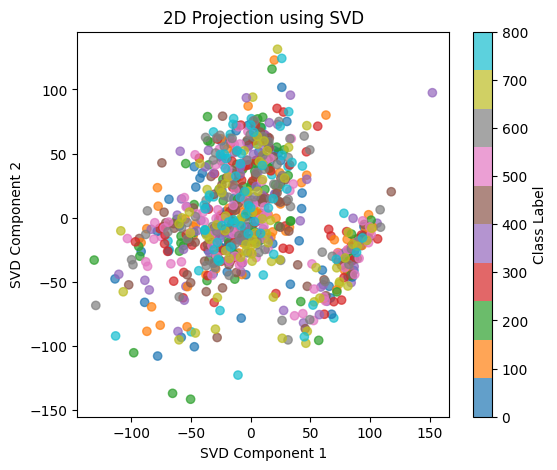

In [28]:
plot_svd_2d(
    U_reduced,
    y_encoded,
    save_path="../results/figures/svd_2d_projection.png"
)


## 3.3 3D SVD Projection

Adding a third SVD component reveals additional separation between cancer types that may overlap in the 2D view. This confirms that the latent space is multi-dimensional and richer structure emerges with more components.

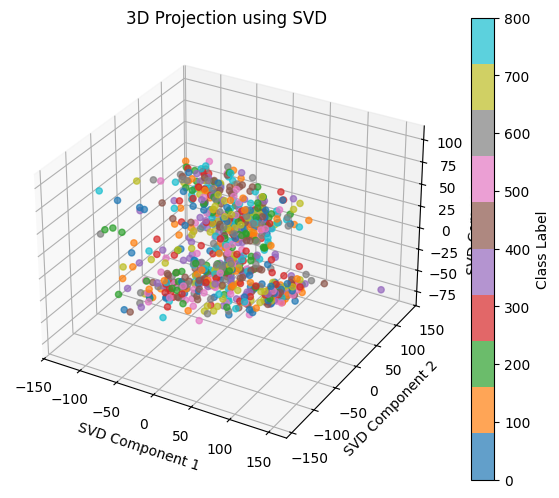

In [29]:
plot_svd_3d(
    U_reduced,
    y_encoded,
    save_path="../results/figures/svd_3d_projection.png"
)


## 3.4 PCA Projection (Comparison)

For validation, we also project the data using PCA (Principal Component Analysis). On centered data, PCA and SVD produce equivalent results. Comparing the two projections confirms that our SVD implementation correctly captures the principal directions of variance.

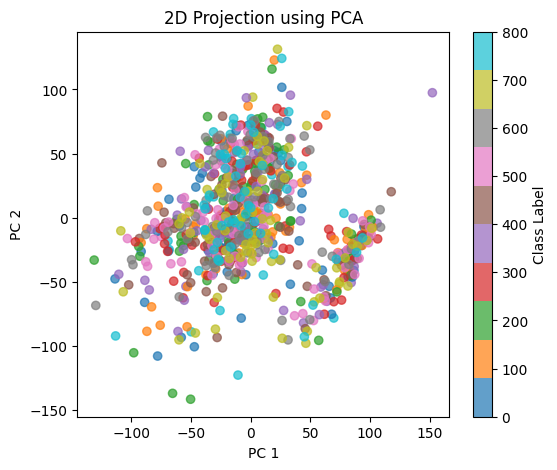

In [30]:
plot_pca_2d(
    X,
    y_encoded,
    save_path="../results/figures/pca_2d_projection.png"
)
